In [ ]:



# Copyright (c) Meta Platforms, Inc. and affiliates.

## Batch image segmentation with SAM 3

This notebook runs SAM 3 text-prompt segmentation on a folder of images in batches, saves per-image predictions, and evaluates the results with the same COCO and pixel-level metrics used in examples/sam3_agent_batch.ipynb.

# <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/sam3/blob/main/notebooks/sam3_image_predictor_example.ipynb">
#   <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
# </a>

In [ ]:
using_colab = False

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [3]:
!module purge
!module load miniforge/25.3.0-3 cuda/12.8
!conda activate sam3


CondaError: Run 'conda init' before 'conda activate'



In [4]:
if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib scikit-learn
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam3.git'

In [5]:
from datetime import datetime
from pathlib import Path
import importlib
import json

from IPython.display import Image, display
import pandas as pd
import sam3
import torch

from sam3 import build_sam3_image_model
from cus_tools.sam3_agent_eval_utils import (
    build_coco_ground_truth,
    compute_pixel_mask_metrics,
    evaluate_coco_predictions,
    expected_agent_paths,
    load_agent_prediction_as_coco,
    save_profile_artifacts,
)
import cus_tools.sam3_batch_predictor_utils as sam3_batch_predictor_utils

importlib.reload(sam3_batch_predictor_utils)
run_batch_text_prompt_inference = sam3_batch_predictor_utils.run_batch_text_prompt_inference

sam3_root = Path(sam3.__file__).resolve().parent.parent

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


/data/run01/scvi576/envs/sam3/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
import torch

# turn on tfloat32 for Ampere GPUs
# https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# use bfloat16 for the entire notebook
torch.autocast("cuda", dtype=torch.bfloat16).__enter__()

# Build Model

In [7]:
#bpe_path = f"{sam3_root}/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
#model = build_sam3_image_model(bpe_path=bpe_path)

In [8]:
ckpt = "ms_cache/facebook/sam3/sam3.pt" # <-- change to your local file

model = build_sam3_image_model(
    checkpoint_path=ckpt,
    load_from_HF=False,
    device="cuda" if torch.cuda.is_available() else "cpu",
    eval_mode=True,
)

In [ ]:
MODEL_NAME = "sam3_batch_predictor"
TEXT_PROMPT = "hexagon"
CONFIDENCE_THRESHOLD = 0.5
POLYGON_SIMPLIFY_EPSILON = 2.0

## Batch Predictor Config

In [ ]:
DATASET_ROOT = Path("data_cus/mmdata_test_1024/50x")
IMAGE_DIR = DATASET_ROOT / "image"
LABEL_DIR = DATASET_ROOT / "label"
SPLIT_NAME = "50x_unsup"
EVAL_MODE = "batched_predictor"
BATCH_SIZE = 4
SHOW_IMAGE_VISUALIZATION = True
APPEND_TO_SUMMARY_CSV = True

if not IMAGE_DIR.is_dir() or not LABEL_DIR.is_dir():
    raise FileNotFoundError(f"Dataset folders are missing under {DATASET_ROOT}")

RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = Path("outputs") / "coco_eval" / SPLIT_NAME / EVAL_MODE / MODEL_NAME / RUN_TIMESTAMP
PREDICTION_OUTPUT_DIR = RUN_DIR / "agent_output"
PREDICTION_ISAT_DIR = RUN_DIR / "pred_isat"
VIS_DIR = RUN_DIR / "vis"
PROFILE_DIR = RUN_DIR / "profile"
PIXEL_DIR = RUN_DIR / "pixel_metrics"
GT_JSON_PATH = RUN_DIR / "gt_coco.json"
PREDICTIONS_JSON_PATH = RUN_DIR / "predictions.json"
METRICS_JSON_PATH = RUN_DIR / f"{RUN_TIMESTAMP}.json"
PROFILE_SUMMARY_JSON_PATH = PROFILE_DIR / "profile_summary.json"
PROFILE_CSV_PATH = PROFILE_DIR / "per_image_profile.csv"
PROFILE_TIME_PLOT = PROFILE_DIR / "per_image_time.png"
PROFILE_MEMORY_PLOT = PROFILE_DIR / "per_image_memory.png"
PIXEL_SUMMARY_CSV_PATH = PIXEL_DIR / "metrics_summary.csv"
SUMMARY_CSV_PATH = Path("assets/50x_unsup_summary.csv")
SUMMARY_COLUMNS = [
    "split",
    "mode",
    "model",
    "coco/segm_mAP",
    "coco/segm_mAP_50",
    "coco/segm_mAP_75",
    "coco/segm_mAP_s",
    "coco/segm_mAP_m",
    "coco/segm_mAP_l",
    "time",
    "data_time",
    "run_dir",
    "metrics_json",
    "vis_dir",
    "profile_dir",
    "profile_summary_json",
    "profile_csv",
    "profile_time_plot",
    "profile_memory_plot",
    "pixel_dir",
    "pixel_summary_csv",
    "pixel_mean_iou",
    "pixel_mean_precision",
    "pixel_mean_recall",
    "pixel_mean_f1",
    "pixel_mean_pred_coverage",
    "pixel_mean_gt_coverage",
    "pixel_num_images",
    "mean_time_ms",
    "median_time_ms",
    "max_time_ms",
    "mean_peak_allocated_mb",
    "median_peak_allocated_mb",
    "max_peak_allocated_mb",
    "mean_peak_reserved_mb",
    "median_peak_reserved_mb",
    "max_peak_reserved_mb",
    "num_images",
    "num_warmup",
]

for output_dir in (RUN_DIR, PREDICTION_OUTPUT_DIR, PREDICTION_ISAT_DIR, VIS_DIR, PROFILE_DIR, PIXEL_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)


def build_result_row(metrics, profile_summary, profile_df):
    return {
        "split": SPLIT_NAME,
        "mode": EVAL_MODE,
        "model": MODEL_NAME,
        "coco/segm_mAP": float(metrics.get("coco_eval_segm_AP", 0.0)),
        "coco/segm_mAP_50": float(metrics.get("coco_eval_segm_AP_50", 0.0)),
        "coco/segm_mAP_75": float(metrics.get("coco_eval_segm_AP_75", 0.0)),
        "coco/segm_mAP_s": float(metrics.get("coco_eval_segm_AP_small", 0.0)),
        "coco/segm_mAP_m": float(metrics.get("coco_eval_segm_AP_medium", 0.0)),
        "coco/segm_mAP_l": float(metrics.get("coco_eval_segm_AP_large", 0.0)),
        "time": float(profile_summary["mean_time_ms"] / 1000.0),
        "data_time": float(profile_df["data_time_s"].mean()),
        "run_dir": str(RUN_DIR),
        "metrics_json": str(METRICS_JSON_PATH),
        "vis_dir": str(VIS_DIR),
        "profile_dir": str(PROFILE_DIR),
        "profile_summary_json": str(PROFILE_SUMMARY_JSON_PATH),
        "profile_csv": str(PROFILE_CSV_PATH),
        "profile_time_plot": str(PROFILE_TIME_PLOT),
        "profile_memory_plot": str(PROFILE_MEMORY_PLOT),
        "pixel_dir": str(metrics.get("pixel_dir", "")),
        "pixel_summary_csv": str(metrics.get("pixel_summary_csv", "")),
        "pixel_mean_iou": float(metrics.get("pixel_mean_iou", 0.0)),
        "pixel_mean_precision": float(metrics.get("pixel_mean_precision", 0.0)),
        "pixel_mean_recall": float(metrics.get("pixel_mean_recall", 0.0)),
        "pixel_mean_f1": float(metrics.get("pixel_mean_f1", 0.0)),
        "pixel_mean_pred_coverage": float(metrics.get("pixel_mean_pred_coverage", 0.0)),
        "pixel_mean_gt_coverage": float(metrics.get("pixel_mean_gt_coverage", 0.0)),
        "pixel_num_images": int(metrics.get("pixel_num_images", 0)),
        "mean_time_ms": float(profile_summary["mean_time_ms"]),
        "median_time_ms": float(profile_summary["median_time_ms"]),
        "max_time_ms": float(profile_summary["max_time_ms"]),
        "mean_peak_allocated_mb": float(profile_summary["mean_peak_allocated_mb"]),
        "median_peak_allocated_mb": float(profile_summary["median_peak_allocated_mb"]),
        "max_peak_allocated_mb": float(profile_summary["max_peak_allocated_mb"]),
        "mean_peak_reserved_mb": float(profile_summary["mean_peak_reserved_mb"]),
        "median_peak_reserved_mb": float(profile_summary["median_peak_reserved_mb"]),
        "max_peak_reserved_mb": float(profile_summary["max_peak_reserved_mb"]),
        "num_images": int(profile_summary["num_images"]),
        "num_warmup": int(profile_summary["num_warmup"]),
    }


print(f"Batch evaluation artifacts will be written to: {RUN_DIR}")

Batch evaluation artifacts will be written to: outputs/coco_eval/50x_unsup/batched_predictor/sam3_batch_predictor/20260526_183404


## Run Batch Inference And Evaluation

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *segm*
DONE (t=0.02s).
Accumulating evaluation results...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.635
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.732
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.656
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.059
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.572
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.773
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.067
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.568
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

,split,mode,model,coco/segm_mAP,coco/segm_mAP_50,coco/segm_mAP_75,coco/segm_mAP_s,coco/segm_mAP_m,coco/segm_mAP_l,time,...,median_time_ms,max_time_ms,mean_peak_allocated_mb,median_peak_allocated_mb,max_peak_allocated_mb,mean_peak_reserved_mb,median_peak_reserved_mb,max_peak_reserved_mb,num_images,num_warmup
0,50x_unsup,batched_predictor,sam3_batch_predictor,0.634757,0.731934,0.656415,0.059406,0.57212,0.77314,1.186187,...,1104.502855,1766.21392,5088.831706,5088.915527,5088.915527,5327.666667,5328.0,5328.0,6,0


,image_name,image_path,prediction_json,prediction_isat,prediction_visual,num_predictions,time_s,time_ms,data_time_s,data_time_ms,peak_allocated_mb,peak_reserved_mb,status,attempt_count,error_message
0,50x-1.png,/data/run01/scvi576/JiaBSH/nano_sam3/data_cus/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,9,1.766214,1766.213920,0.001046,1.045549,5088.412598,5326.0,generated,1,
1,50x-2.png,/data/run01/scvi576/JiaBSH/nano_sam3/data_cus/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,13,1.116563,1116.562814,0.001046,1.045549,5088.915527,5328.0,generated,1,
2,50x-3.png,/data/run01/scvi576/JiaBSH/nano_sam3/data_cus/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,12,1.012997,1012.997445,0.001046,1.045549,5088.915527,5328.0,generated,1,
3,50x-4.png,/data/run01/scvi576/JiaBSH/nano_sam3/data_cus/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,12,1.092443,1092.442896,0.001046,1.045549,5088.915527,5328.0,generated,1,
4,50x-5.png,/data/run01/scvi576/JiaBSH/nano_sam3/data_cus/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,9,0.976040,976.039577,0.000374,0.374421,5088.915527,5328.0,generated,1,
5,50x-6.png,/data/run01/scvi576/JiaBSH/nano_sam3/data_cus/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,outputs/coco_eval/50x_unsup/batched_predictor/...,13,1.152863,1152.863029,0.000374,0.374421,5088.915527,5328.0,generated,1,


,image_id,image_name,iou,precision,recall,f1,pred_coverage,gt_coverage,tp,fp,fn
0,1,50x-1.png,0.973376,0.989183,0.983849,0.986509,0.407635,0.409845,281187,3075,4616
1,2,50x-2.png,0.981364,0.997119,0.984154,0.990594,0.391229,0.396383,272035,786,4380
2,3,50x-3.png,0.973259,0.993652,0.979348,0.986448,0.283950,0.288097,196754,1257,4149
3,4,50x-4.png,0.974389,0.994816,0.979361,0.987028,0.530866,0.539243,368277,1919,7761
4,5,50x-5.png,0.971559,0.993275,0.977992,0.985574,0.352275,0.357780,244005,1652,5491
5,6,50x-6.png,0.954332,0.992565,0.961204,0.976633,0.399827,0.412872,276744,2073,11170


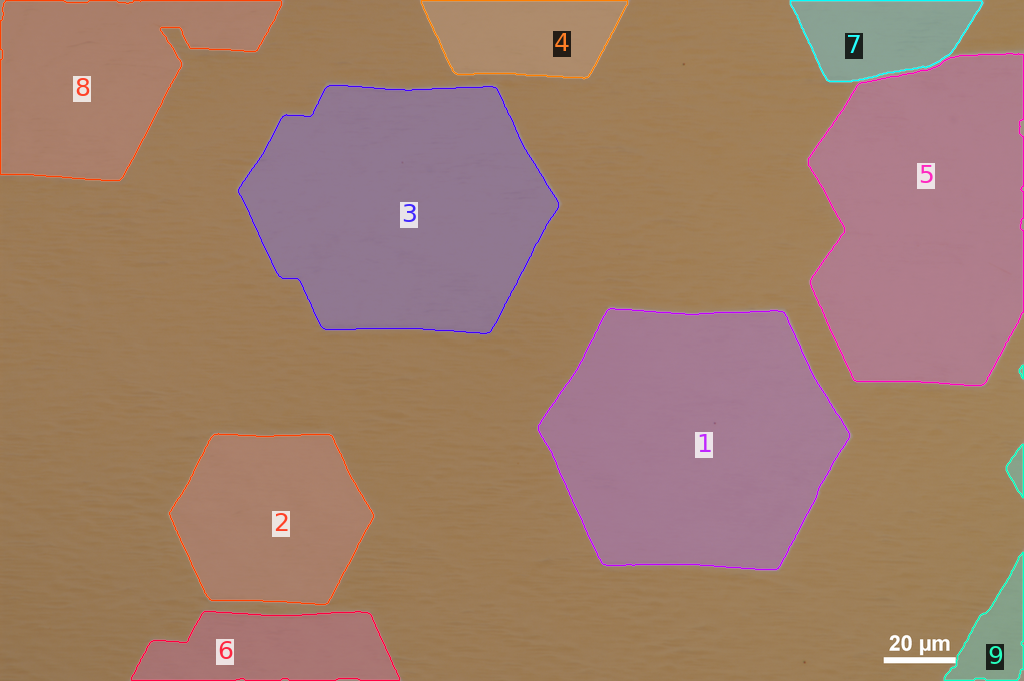

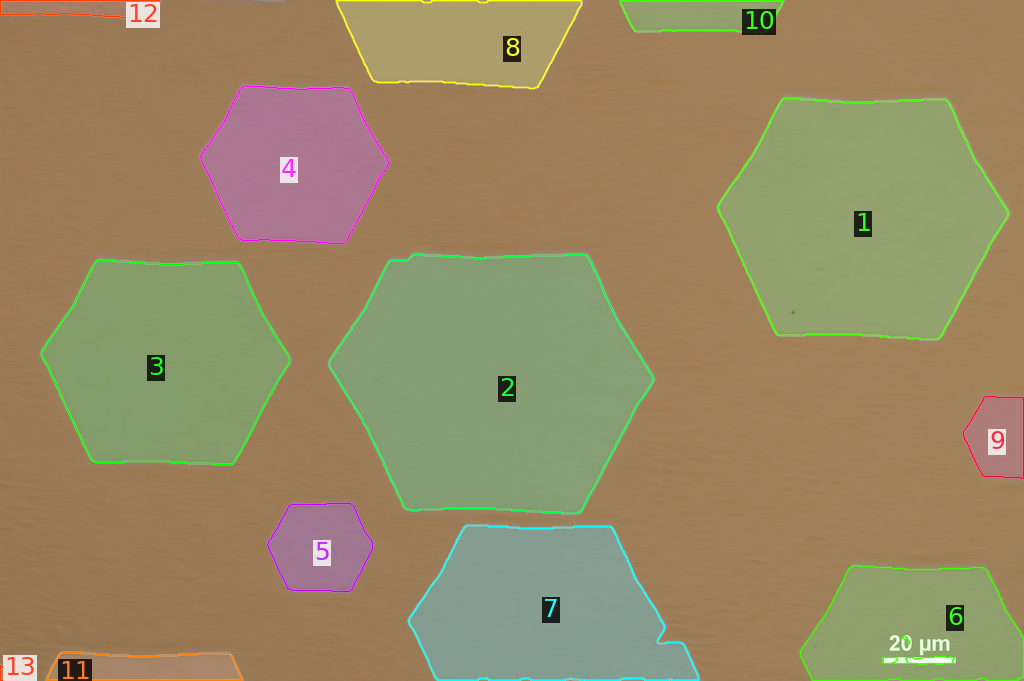

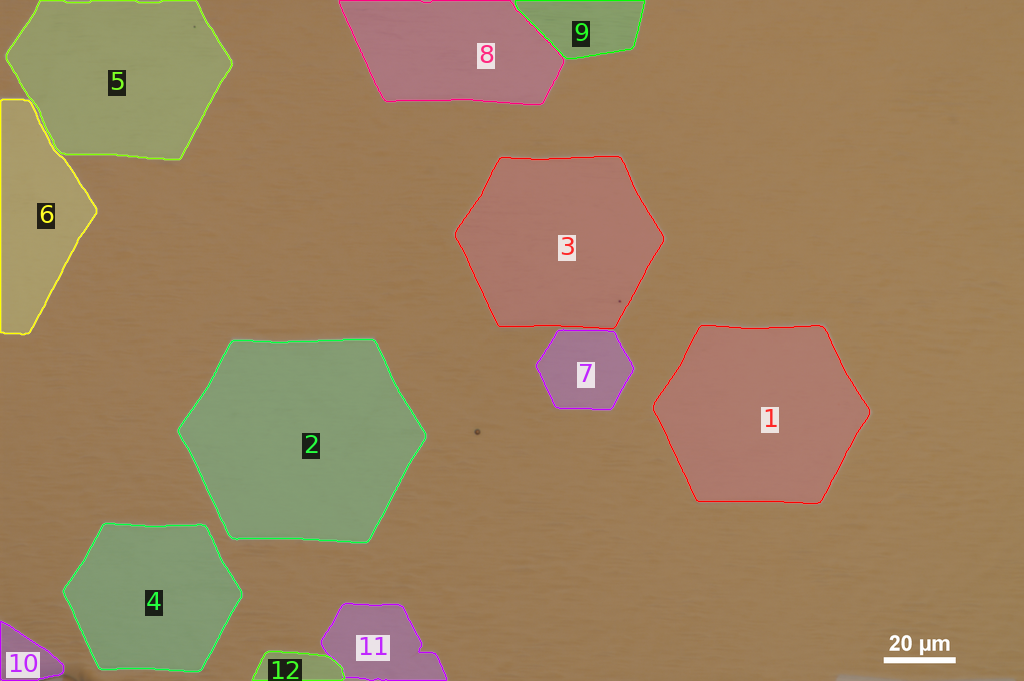

,split,mode,model,coco/segm_mAP,coco/segm_mAP_50,coco/segm_mAP_75,coco/segm_mAP_s,coco/segm_mAP_m,coco/segm_mAP_l,time,...,median_time_ms,max_time_ms,mean_peak_allocated_mb,median_peak_allocated_mb,max_peak_allocated_mb,mean_peak_reserved_mb,median_peak_reserved_mb,max_peak_reserved_mb,num_images,num_warmup
0,50x_unsup,batched_predictor,sam3_batch_predictor,0.634757,0.731934,0.656415,0.059406,0.57212,0.77314,1.186187,...,1104.502855,1766.21392,5088.831706,5088.915527,5088.915527,5327.666667,5328.0,5328.0,6,0


In [11]:
gt_dataset, image_lookup = build_coco_ground_truth(LABEL_DIR, GT_JSON_PATH)

profile_df = run_batch_text_prompt_inference(
    model=model,
    image_lookup=image_lookup,
    image_dir=IMAGE_DIR,
    text_prompt=TEXT_PROMPT,
    model_name=MODEL_NAME,
    output_dir=PREDICTION_OUTPUT_DIR,
    vis_dir=VIS_DIR,
    isat_output_dir=PREDICTION_ISAT_DIR,
    batch_size=BATCH_SIZE,
    confidence_threshold=CONFIDENCE_THRESHOLD,
    polygon_simplify_epsilon=POLYGON_SIMPLIFY_EPSILON,
 )

predictions = []
next_annotation_id = 1
for image_name in sorted(image_lookup):
    image_info = image_lookup[image_name]
    image_path = (IMAGE_DIR / image_name).resolve()
    prediction_path, _, _ = expected_agent_paths(
        image_path=image_path,
        text_prompt=TEXT_PROMPT,
        llm_name=MODEL_NAME,
        output_dir=PREDICTION_OUTPUT_DIR,
    )
    if prediction_path.exists():
        image_predictions, next_annotation_id = load_agent_prediction_as_coco(
            prediction_path,
            image_info,
            next_annotation_id,
            polygon_simplify_epsilon=POLYGON_SIMPLIFY_EPSILON,
        )
        predictions.extend(image_predictions)
    else:
        print(f"[WARN] Missing prediction file: {prediction_path}")

predictions_payload = {
    "images": gt_dataset["images"],
    "annotations": predictions,
    "categories": gt_dataset["categories"],
}

with PREDICTIONS_JSON_PATH.open("w", encoding="utf-8") as handle:
    json.dump(predictions_payload, handle, indent=2, ensure_ascii=False)

metrics = evaluate_coco_predictions(GT_JSON_PATH, PREDICTIONS_JSON_PATH)
pixel_metrics, pixel_df = compute_pixel_mask_metrics(gt_dataset, predictions, PIXEL_SUMMARY_CSV_PATH)
metrics.update(pixel_metrics)
metrics["pixel_dir"] = str(PIXEL_DIR)
metrics["pixel_summary_csv"] = str(PIXEL_SUMMARY_CSV_PATH)

profile_summary = save_profile_artifacts(
    profile_df=profile_df,
    profile_csv_path=PROFILE_CSV_PATH,
    profile_summary_json_path=PROFILE_SUMMARY_JSON_PATH,
    profile_time_plot=PROFILE_TIME_PLOT,
    profile_memory_plot=PROFILE_MEMORY_PLOT,
)
result_row = build_result_row(metrics, profile_summary, profile_df)
result_row = {column: result_row.get(column) for column in SUMMARY_COLUMNS}

metrics_payload = {
    "metrics": metrics,
    "pixel_metrics": pixel_metrics,
    "pixel_summary_csv": str(PIXEL_SUMMARY_CSV_PATH),
    "profile_summary": profile_summary,
    "result_row": result_row,
    "ground_truth_json": str(GT_JSON_PATH),
    "predictions_json": str(PREDICTIONS_JSON_PATH),
    "prediction_isat_dir": str(PREDICTION_ISAT_DIR),
    "text_prompt": TEXT_PROMPT,
    "batch_size": BATCH_SIZE,
    "confidence_threshold": CONFIDENCE_THRESHOLD,
    "polygon_simplify_epsilon": POLYGON_SIMPLIFY_EPSILON,
}
with METRICS_JSON_PATH.open("w", encoding="utf-8") as handle:
    json.dump(metrics_payload, handle, indent=2, ensure_ascii=False)

result_df = pd.DataFrame([result_row], columns=SUMMARY_COLUMNS)
display(result_df)
display(profile_df)
display(pixel_df)

if SHOW_IMAGE_VISUALIZATION:
    successful_visuals = [
        visual_path
        for visual_path in sorted(VIS_DIR.glob("*.png"))
        if visual_path.exists()
    ][:3]
    for visual_path in successful_visuals:
        display(Image(filename=str(visual_path)))

result_df

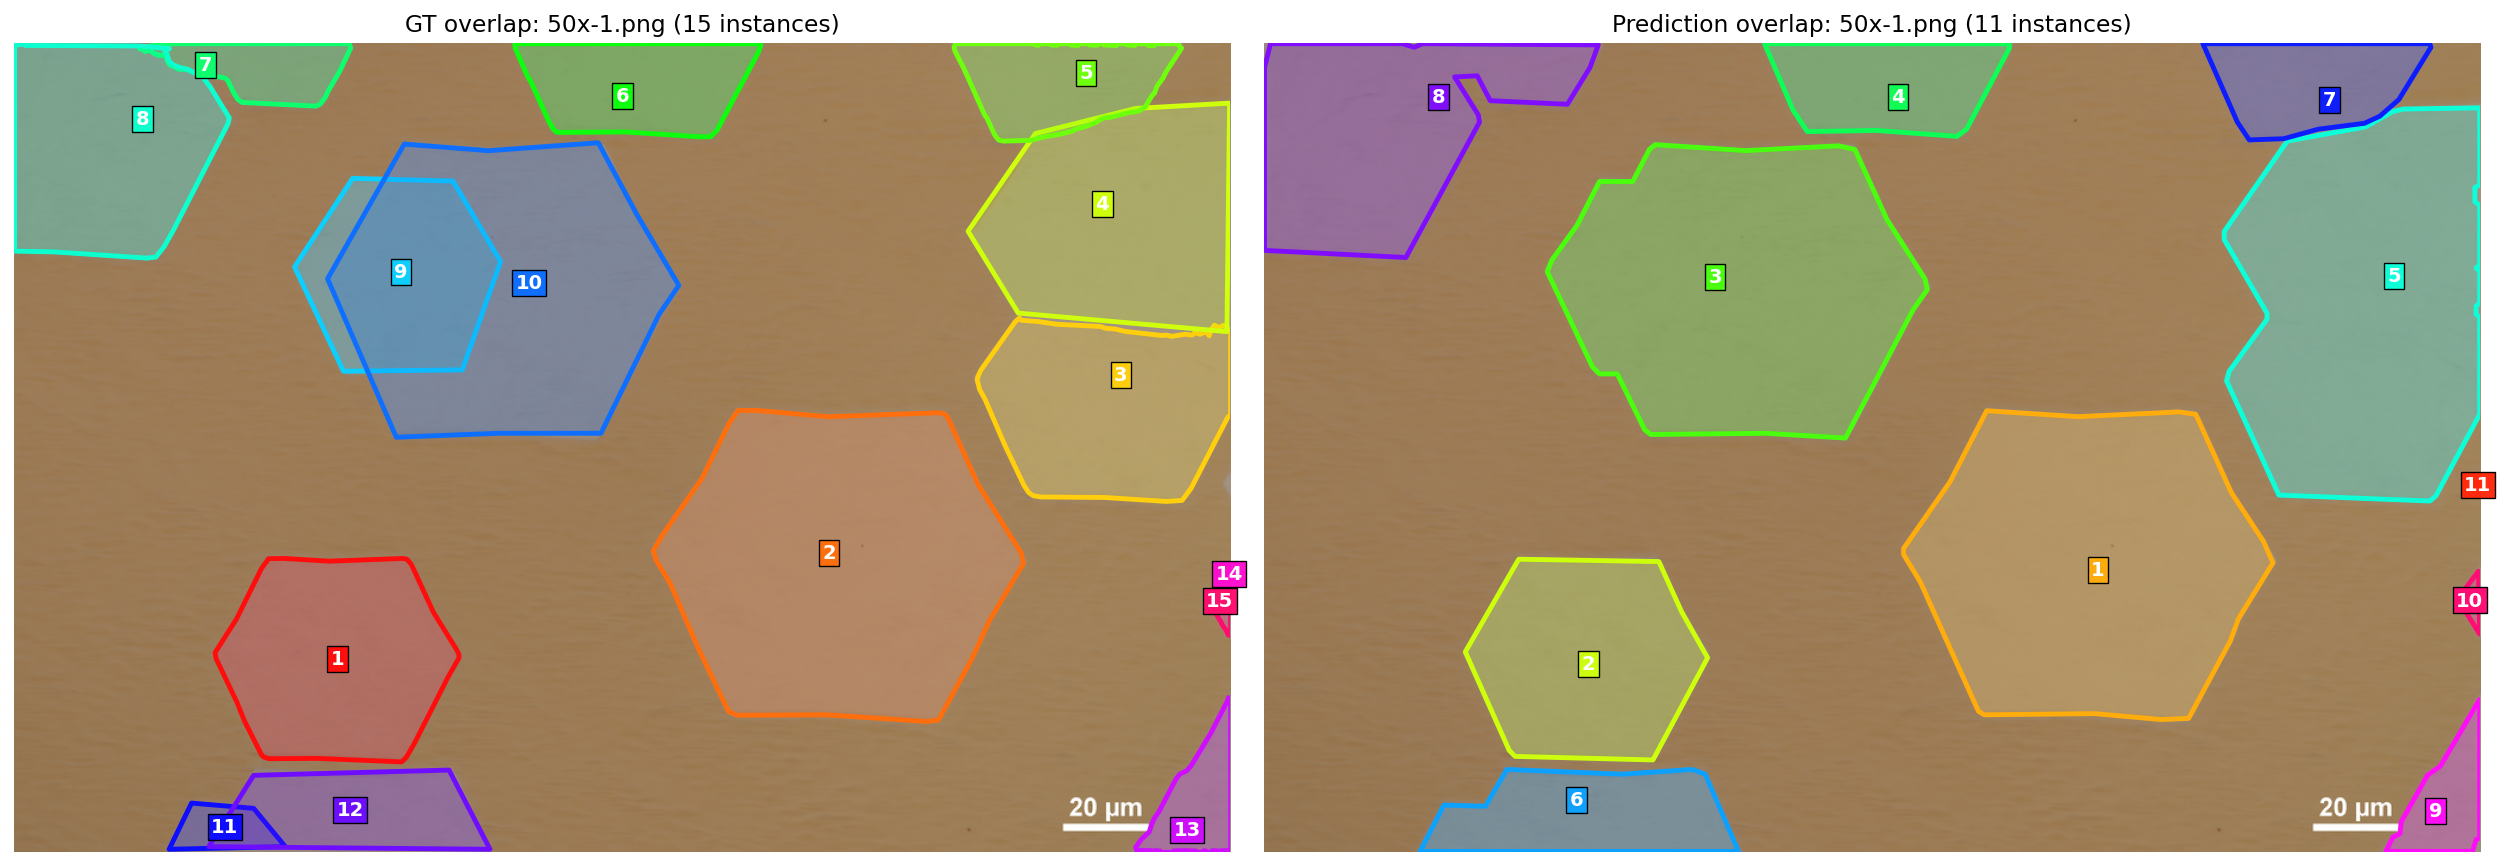

Visualization mode: overlap on original image with per-instance colors
GT JSON: data_cus/mmdata_test_1024/50x/label/50x-1.json
Prediction iSAT JSON: outputs/coco_eval/50x_unsup/batched_predictor/sam3_batch_predictor/20260526_183404/pred_isat/50x-1.json


In [12]:
compare_candidates = sorted(
    pred_path.name
    for pred_path in PREDICTION_ISAT_DIR.glob("*.json")
    if (LABEL_DIR / pred_path.name).exists()
    and (IMAGE_DIR / pred_path.with_suffix(".png").name).exists()
 )

if not compare_candidates:
    raise FileNotFoundError(
        f"No matching GT/prediction iSAT JSON pairs found under {LABEL_DIR} and {PREDICTION_ISAT_DIR}."
    )

COMPARE_IMAGE_NAME = compare_candidates[0].replace(".json", ".png")
gt_isat_path = LABEL_DIR / f"{Path(COMPARE_IMAGE_NAME).stem}.json"
pred_isat_path = PREDICTION_ISAT_DIR / f"{Path(COMPARE_IMAGE_NAME).stem}.json"
image_path = IMAGE_DIR / COMPARE_IMAGE_NAME

with gt_isat_path.open("r", encoding="utf-8") as handle:
    gt_isat = json.load(handle)
with pred_isat_path.open("r", encoding="utf-8") as handle:
    pred_isat = json.load(handle)

from PIL import Image as PILImage
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib import colors as mcolors
import numpy as np

def _looks_like_point(candidate):
    return (
        isinstance(candidate, (list, tuple))
        and len(candidate) == 2
        and all(isinstance(value, (int, float)) for value in candidate)
    )

def _collect_polygons(payload):
    polygons = []
    for obj in payload.get("objects", []):
        segmentation = obj.get("segmentation", [])
        if not segmentation:
            continue
        if all(_looks_like_point(point) for point in segmentation):
            polygons.append(segmentation)
            continue
        for candidate in segmentation:
            if isinstance(candidate, (list, tuple)) and all(_looks_like_point(point) for point in candidate):
                polygons.append(candidate)
    return polygons

def _instance_colors(num_instances, hue_offset=0.0):
    if num_instances <= 0:
        return []
    hues = (np.linspace(0.0, 1.0, num_instances, endpoint=False) + hue_offset) % 1.0
    return [mcolors.hsv_to_rgb((float(hue), 0.95, 1.0)) for hue in hues]

def _polygon_center(polygon):
    polygon_array = np.asarray(polygon, dtype=float)
    return polygon_array[:, 0].mean(), polygon_array[:, 1].mean()

image = np.asarray(PILImage.open(image_path).convert("RGB"))
gt_polygons = _collect_polygons(gt_isat)
pred_polygons = _collect_polygons(pred_isat)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=140)
for axis, polygons, title, hue_offset in [
    (axes[0], gt_polygons, f"GT overlap: {COMPARE_IMAGE_NAME} ({len(gt_polygons)} instances)", 0.00),
    (axes[1], pred_polygons, f"Prediction overlap: {COMPARE_IMAGE_NAME} ({len(pred_polygons)} instances)", 0.11),
]:
    axis.imshow(image)
    instance_colors = _instance_colors(len(polygons), hue_offset=hue_offset)
    for index, (polygon, instance_color) in enumerate(zip(polygons, instance_colors), start=1):
        axis.add_patch(
            Polygon(
                polygon,
                closed=True,
                facecolor=(*instance_color, 0.22),
                edgecolor=instance_color,
                linewidth=2.5,
                joinstyle="round",
                zorder=3,
            )
        )
        center_x, center_y = _polygon_center(polygon)
        axis.text(
            center_x,
            center_y,
            str(index),
            color="white",
            fontsize=10,
            fontweight="bold",
            ha="center",
            va="center",
            zorder=4,
            bbox={"facecolor": (*instance_color, 0.98), "edgecolor": "black", "linewidth": 0.7, "pad": 1.8},
        )
    axis.set_title(title)
    axis.set_axis_off()

plt.tight_layout()
plt.show()

print("Visualization mode: overlap on original image with per-instance colors")
print(f"GT JSON: {gt_isat_path}")
print(f"Prediction iSAT JSON: {pred_isat_path}")

## Append Summary CSV

In [ ]:
if APPEND_TO_SUMMARY_CSV:
    if SUMMARY_CSV_PATH.exists():
        summary_df = pd.read_csv(SUMMARY_CSV_PATH)
        summary_df = summary_df.reindex(columns=SUMMARY_COLUMNS)
    else:
        summary_df = pd.DataFrame(columns=SUMMARY_COLUMNS)
    new_row_df = pd.DataFrame([result_row], columns=SUMMARY_COLUMNS)
    summary_df = pd.concat([summary_df, new_row_df], ignore_index=True)
    summary_df.to_csv(SUMMARY_CSV_PATH, index=False)
    print(f"Appended 1 row to {SUMMARY_CSV_PATH}")
else:
    print("Set APPEND_TO_SUMMARY_CSV = True in the previous cell if you want to append the new row to assets/50x_unsup_summary.csv.")

result_df

Appended 1 row to assets/50x_unsup_summary.csv


,split,mode,model,coco/segm_mAP,coco/segm_mAP_50,coco/segm_mAP_75,coco/segm_mAP_s,coco/segm_mAP_m,coco/segm_mAP_l,time,...,median_time_ms,max_time_ms,mean_peak_allocated_mb,median_peak_allocated_mb,max_peak_allocated_mb,mean_peak_reserved_mb,median_peak_reserved_mb,max_peak_reserved_mb,num_images,num_warmup
0,50x_unsup,batched_predictor,sam3_batch_predictor,0.634757,0.731934,0.656415,0.059406,0.57212,0.77314,1.186187,...,1104.502855,1766.21392,5088.831706,5088.915527,5088.915527,5327.666667,5328.0,5328.0,6,0
